<a href="https://colab.research.google.com/github/missaelrmzport-create/jueves-lap/blob/main/Practica_Analitica_Alvarado_Gabriela_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("/content/datasets/Spotify_Youtube.csv", index_col=0)
data.head()
data.shape

(20718, 27)

In [ ]:
null_counts = data.isnull().sum()
columns_to_drop = null_counts.loc[null_counts > (0.03 * len(data))].index

data_cleaned = data.drop(columns=columns_to_drop)
data_cleaned.shape

(20718, 26)

In [ ]:
numeric_columns = data_cleaned.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
    data_cleaned[col].fillna(data_cleaned[col].median(), inplace=True)

data_cleaned.isnull().sum()

/tmp/ipython-input-4219507637.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].median(), inplace=True)


,0
Artist,0
Url_spotify,0
Track,0
Album,0
Album_type,0
Uri,0
Danceability,0
Energy,0
Key,0
Loudness,0


In [ ]:
string_columns = data_cleaned.select_dtypes(include=['object']).columns
string_columns

Index(['Artist', 'Url_spotify', 'Track', 'Album', 'Album_type', 'Uri',
       'Url_youtube', 'Title', 'Channel', 'Licensed', 'official_video'],
      dtype='object')

In [ ]:
string_columns = data_cleaned.select_dtypes(include=['object']).columns

for col in string_columns:
    data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)

/tmp/ipython-input-2740329540.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)
/tmp/ipython-input-2740329540.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_cleaned[col].fillna(data_cleaned[col].mode()[0], inplace=True)


In [ ]:
descritive_stats = data_cleaned[['Views','Likes','Comments','Stream']].describe()
median_stats = data_cleaned[['Views','Likes','Comments','Stream']].median()
descritive_stats.loc['median'] = median_stats
descritive_stats

,Views,Likes,Comments,Stream
count,2.071800e+04,2.071800e+04,2.071800e+04,2.071800e+04
mean,9.213575e+07,6.492700e+05,2.685321e+04,1.335440e+08
std,2.717686e+08,1.767896e+06,1.906038e+05,2.411317e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,6.574000e+03
25%,1.950563e+06,2.302175e+04,5.420000e+02,1.825666e+07
50%,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07
75%,6.749228e+07,4.996608e+05,1.372900e+04,1.337912e+08
max,8.079649e+09,5.078865e+07,1.608314e+07,3.386520e+09
median,1.450110e+07,1.244810e+05,3.277000e+03,4.968298e+07


In [ ]:
# filtrar canciones > 500 millones
top_youtube = data_cleaned.loc[data_cleaned['Views'] > 500000000]
top_youtube.shape

(835, 26)

In [ ]:
# crear una columna de rendimiento
top_youtube['likes_to_views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)
top_youtube

/tmp/ipython-input-179504219.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_youtube['likes_to_views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)


,Artist,Url_spotify,Track,Album,Album_type,Uri,Danceability,Energy,Key,Loudness,...,Url_youtube,Title,Channel,Views,Likes,Comments,Licensed,official_video,Stream,likes_to_views
0,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Feel Good Inc.,Demon Days,album,spotify:track:0d28khcov6AiegSCpG5TuT,0.818,0.705,6.0,-6.679,...,https://www.youtube.com/watch?v=HyHNuVaZJ-k,Gorillaz - Feel Good Inc. (Official Video),Gorillaz,6.935552e+08,6220896.0,169907.0,True,True,1.040235e+09,0.01
4,Gorillaz,https://open.spotify.com/artist/3AA28KZvwAUcZu...,Clint Eastwood,Gorillaz,album,spotify:track:7yMiX7n9SBvadzox8T5jzT,0.663,0.694,10.0,-8.627,...,https://www.youtube.com/watch?v=1V_xRb0x9aw,Gorillaz - Clint Eastwood (Official Video),Gorillaz,6.184810e+08,6197318.0,155930.0,True,True,6.172597e+08,0.01
10,Red Hot Chili Peppers,https://open.spotify.com/artist/0L8ExT028jH3dd...,Californication,Californication (Deluxe Edition),album,spotify:track:48UPSzbZjgc449aqz8bxox,0.592,0.767,9.0,-2.788,...,https://www.youtube.com/watch?v=YlUKcNNmywk,Red Hot Chili Peppers - Californication (Offic...,Red Hot Chili Peppers,1.018811e+09,4394471.0,121452.0,True,True,1.055738e+09,0.00
14,Red Hot Chili Peppers,https://open.spotify.com/artist/0L8ExT028jH3dd...,Otherside,Californication (Deluxe Edition),album,spotify:track:64BbK9SFKH2jk86U3dGj2P,0.458,0.795,0.0,-3.265,...,https://www.youtube.com/watch?v=rn_YodiJO6k,Red Hot Chili Peppers - Otherside [Official Mu...,Red Hot Chili Peppers,6.735287e+08,3140356.0,60091.0,True,True,7.327745e+08,0.00
20,50 Cent,https://open.spotify.com/artist/3q7HBObVc0L8jN...,In Da Club,Get Rich Or Die Tryin',album,spotify:track:4RY96Asd9IefaL3X4LOLZ8,0.902,0.720,6.0,-2.776,...,https://www.youtube.com/watch?v=5qm8PH4xAss,50 Cent - In Da Club (Official Music Video),50CentVEVO,1.682616e+09,10481678.0,296745.0,True,True,1.041737e+09,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20307,CoComelon,https://open.spotify.com/artist/6SXTTUJxIVwMbc...,Itsy Bitsy Spider,"CoComelon Kids Hits, Vol. 1",album,spotify:track:6cKlr2BOXBaqiuaHUY5Zwo,0.919,0.289,2.0,-12.244,...,https://www.youtube.com/watch?v=ljHGusbX7Bk,Itsy Bitsy Spider + More Nursery Rhymes & Kids...,Cocomelon - Nursery Rhymes,5.869377e+08,1942075.0,0.0,True,True,3.978538e+07,0.00
20308,CoComelon,https://open.spotify.com/artist/6SXTTUJxIVwMbc...,Baby Shark,Nursery Rhymes by CoComelon,album,spotify:track:7zD97mcPo9fng0aJqUhFvd,0.779,0.587,7.0,-8.131,...,https://www.youtube.com/watch?v=020g-0hhCAU,Baby Shark | CoComelon Nursery Rhymes & Kids S...,Cocomelon - Nursery Rhymes,2.645859e+09,6604353.0,0.0,True,True,2.263272e+07,0.00
20309,CoComelon,https://open.spotify.com/artist/6SXTTUJxIVwMbc...,Old MacDonald,"CoComelon Kids Hits, Vol. 1",album,spotify:track:5txSLkf7BeYIgTtUnVDDG8,0.704,0.479,1.0,-12.362,...,https://www.youtube.com/watch?v=Wm4R8d0d8kU,Old MacDonald | CoComelon Nursery Rhymes & Kid...,Cocomelon - Nursery Rhymes,1.545924e+09,5397846.0,0.0,True,True,2.793820e+07,0.00
20310,CoComelon,https://open.spotify.com/artist/6SXTTUJxIVwMbc...,Finger Family,"CoComelon Kids Hits, Vol. 2",album,spotify:track:679VCjP1C3DBkVBEeB34yU,0.816,0.565,9.0,-11.555,...,https://www.youtube.com/watch?v=hqr46XZhtRg,Finger Family + More Nursery Rhymes & Kids Son...,Cocomelon - Nursery Rhymes,5.160842e+08,1714627.0,0.0,True,True,2.684379e+07,0.00


In [ ]:
# Crear la nueva columna "Likes_to_Views" como proporción de Likes respecto a Views
top_youtube['Likes_to_Views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)

# Agrupar por "Album_type" y calcular estadísticas
album_analysis = top_youtube.groupby('Album_type').agg({
    'Energy': ['mean', 'median'],
    'Danceability': ['mean', 'median'],
    'Views': 'sum',
    'Stream': 'sum'
}).reset_index()

print(album_analysis.head())


    Album_type    Energy         Danceability                Views  \
                    mean  median         mean median           sum   
0        album  0.683681  0.7095     0.670642  0.692  7.055829e+11   
1  compilation  0.644563  0.6810     0.680406  0.734  2.843627e+10   
2       single  0.683443  0.6720     0.694234  0.727  1.722522e+11   

         Stream  
            sum  
0  5.216714e+11  
1  9.327303e+09  
2  9.019371e+10  


/tmp/ipython-input-3551823639.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_youtube['Likes_to_Views'] = (top_youtube['Likes'] / top_youtube['Views']).round(2)


In [ ]:
# Filtrar canciones con proporción "Likes_to_Views" menor a 0.01
low_likes = top_youtube[top_youtube['Likes_to_Views'] < 0.01]

# Calcular el número total de canciones por "Album_type"
low_likes_summary = low_likes.groupby('Album_type').size().reset_index(name='count')

low_likes_summary.head()


,Album_type,count
0,album,259
1,compilation,10
2,single,63


/tmp/ipython-input-1216975028.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Album Type')


<Axes: title={'center': 'Relación entre Energy y Stream para canciones con baja proporción de Likes'}, xlabel='Energy', ylabel='Stream (promedio)'>

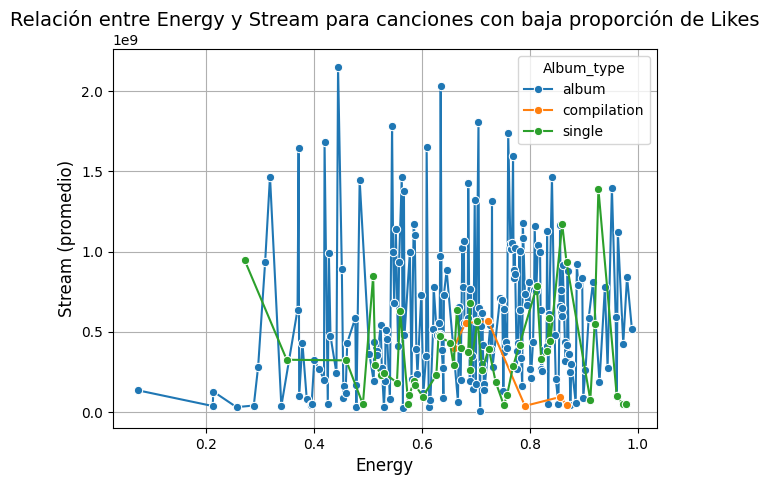

In [ ]:
# Promedio de "Stream" por "Energy" y "Album_type" en el subconjunto `low_likes`
trend_data = low_likes.groupby(['Album_type', 'Energy']).agg({'Stream': 'mean'}).reset_index()

# Personalizar el gráfico
plt.title('Relación entre Energy y Stream para canciones con baja proporción de Likes', fontsize=14)
plt.xlabel('Energy', fontsize=12)
plt.ylabel('Stream (promedio)', fontsize=12)
plt.legend(title='Album Type')
plt.grid(True)
plt.tight_layout()

sns.lineplot(data=trend_data, x='Energy', y='Stream', hue='Album_type', marker='o')


<Axes: title={'center': 'Mapa de calor de promedio de bailabilidad según el tipo de canción'}, ylabel='Album_type'>

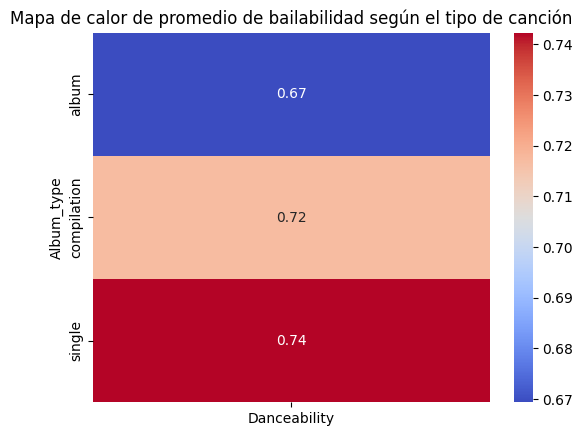

In [ ]:
# Crear datos para el mapa de calor: promedio de "Danceability" por tipo de álbum
heatmap_data = low_likes.groupby('Album_type', as_index=False)['Danceability'].mean().set_index('Album_type')

# Personalizar el mapa de calor
plt.title('Mapa de calor de promedio de bailabilidad según el tipo de canción')
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f')


       Artist        Stream
0   Sam Smith  4.775585e+09
1  Katy Perry  4.655496e+09
2     Rihanna  4.641587e+09


/tmp/ipython-input-368017562.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_artists, x='Artist', y='Stream', palette='viridis')


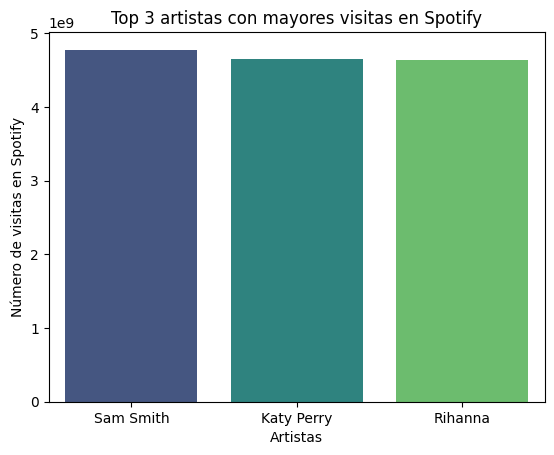

In [ ]:
# Identificar los tres artistas con el mayor total de "Stream"
top_artists = low_likes.groupby('Artist')['Stream'].sum().sort_values(ascending=False).reset_index().head(3)

# Personalizar el gráfico
plt.title('Top 3 artistas con mayores visitas en Spotify')
plt.xlabel('Artistas')
plt.ylabel('Número de visitas en Spotify')

# Crear un gráfico de barras para comparar los totales
sns.barplot(data=top_artists, x='Artist', y='Stream', palette='viridis')

# Mostrar los datos del análisis
print(top_artists)
